In [ ]:
# Standard libraries
import os
# Data manipulation and numerical computation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn utilities
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
sns.set(style="ticks", context="notebook", palette="deep")
pd.set_option('display.max_columns', None)
palette = {'Bad':'#b2182b','Poor':'#d6604d','Moderate':'#f1a340','Good':'#5aae61','High':'#1b7837'}

In [3]:
path = "../../data/processed/"
dfs = {}

# read 03_CLEAN_COMPLETE_DF.parquet
df = pd.read_parquet(os.path.join(path, "taxones_pressure_train.parquet"))

# change unassessed values to NaN
df = df.replace("Unassessed", np.nan)
df = df.replace("None", np.nan)

# index SamplingOperations_code
df = df.set_index('SamplingOperations_code')
 
# DROP HERlvl2Code	Altitude Longitude_Lambert93	Latitude_Lambert93	Watershed	CodeDepartement	HERlvl1Code
df = df.drop(columns=['HERlvl2Code', 'HERlvl2Name', 'HERlvl1Name', 'Altitude','Longitude_Lambert93','Latitude_Lambert93','Watershed','CodeDepartement', 'CodeSite_SamplingOperations', 'Date_SamplingOperation'])
df

TotalAbundance_SamplingOperation  Achaa01  Achac01  \
SamplingOperations_code                                                       
S02000008_20170703                                    405      NaN      NaN   
S02000008_20200708                                    400      NaN      NaN   
S02000010_20070906                                    400      NaN      NaN   
S02000010_20090721                                    400      NaN      NaN   
S02000010_20110723                                    398      NaN      NaN   
...                                                   ...      ...      ...   
S06999141_20160928                                    403      NaN      NaN   
S06999179_20230628                                    409      NaN      NaN   
S06999180_20160928                                    404      NaN      NaN   
S06999189_20160928                                    403      NaN      NaN   
S06999189_20220920                                    406      NaN      NaN   

                         Achaf01  Achaf02  Achal01  Acham01  Achan01  Achat01  \
SamplingOperations_code                                                         
S02000008_20170703           NaN      NaN      NaN      NaN      NaN      NaN   
S02000008_20200708           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20070906           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20090721           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20110723           NaN      NaN      NaN      NaN      NaN      NaN   
...                          ...      ...      ...      ...      ...      ...   
S06999141_20160928           NaN      NaN      NaN      NaN      NaN      NaN   
S06999179_20230628           NaN      NaN      NaN      NaN      NaN      NaN   
S06999180_20160928           NaN      NaN      NaN      NaN      NaN      NaN   
S06999189_20160928           NaN  2.48139      NaN      NaN      NaN      NaN   
S06999189_20220920           NaN      NaN      NaN      NaN      NaN      NaN   

                          Achat02  Achat03  Achba01  Achbi01  Achbi02  \
SamplingOperations_code                                                 
S02000008_20170703            NaN      NaN      NaN      NaN      NaN   
S02000008_20200708            NaN      NaN      NaN      NaN      NaN   
S02000010_20070906            NaN      NaN      NaN      NaN      NaN   
S02000010_20090721            NaN      NaN      NaN      NaN      NaN   
S02000010_20110723            NaN      NaN      NaN      NaN      NaN   
...                           ...      ...      ...      ...      ...   
S06999141_20160928            NaN      NaN      NaN      NaN      NaN   
S06999179_20230628            NaN      NaN      NaN      NaN      NaN   
S06999180_20160928            NaN      NaN      NaN      NaN      NaN   
S06999189_20160928            NaN      NaN      NaN      NaN      NaN   
S06999189_20220920       4.926108      NaN      NaN      NaN      NaN   

                         Achbr01  Achca01  Achca02  Achca03  Achca04  Achch01  \
SamplingOperations_code                                                         
S02000008_20170703           NaN      NaN      NaN      NaN      NaN      NaN   
S02000008_20200708           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20070906           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20090721           NaN      NaN      NaN      NaN      NaN      NaN   
S02000010_20110723           NaN      NaN      NaN      NaN      NaN      NaN   
...                          ...      ...      ...      ...      ...      ...   
S06999141_20160928           NaN      NaN      NaN      NaN      NaN      NaN   
S06999179_20230628           NaN      NaN      NaN      NaN      NaN      NaN   
S06999180_20160928           NaN      NaN      NaN      NaN      NaN      NaN   
S06999189_20160928           NaN      NaN      NaN      NaN      NaN      NaN   
S06999189_20220920   

# For all regions

In [ ]:
import cleandf

Xclean = cleandf.IWANTMYXCLEAN(df)
Xclean 

Dropped exact duplicate columns: ['Actde01', 'Adlaq01', 'Birbi01', 'Calla01', 'Cenre01', 'Cochu02', 'Cocps01', 'Cycex01', 'Cyman04', 'Cymel02', 'Cympr01', 'Diavi01', 'Dipbo02', 'Dipde01', 'Dippa01', 'Enchu01', 'Encla01', 'Encsu01', 'Encsu02', 'Ethpu01', 'Eucau01', 'Eungi01', 'Frape02', 'Gomca03', 'Grama01', 'Hipps01', 'Meldi02', 'Melly01', 'Melny01', 'Mesme01', 'Navel01', 'Navge03', 'Navgr02', 'Navha08', 'Navin02', 'Navme02', 'Navmo10', 'Navpa03', 'Navpa06', 'Navpe02', 'Navra03', 'Navre01', 'Navre06', 'Navsc05', 'Navsu17', 'Navsy02', 'Navth01', 'Navto01', 'Navtr01', 'Navum02', 'Nitla04', 'Nitmi04', 'Nitpl01', 'Nitta01', 'Nitth01', 'Nitzu01', 'Nuppa01', 'Parhe01', 'Pinin03', 'Pinsu08', 'Plala01', 'Plame01', 'Plami01', 'Plata01', 'Psebo01', 'Semro01', 'Stapo01', 'Stapu01', 'Surol01', 'Synaf01', 'Thani01']
Dropped columns with >95% missing: ['Achaa01', 'Achac01', 'Achaf01', 'Achaf02', 'Achal01', 'Acham01', 'Achan01', 'Achat01', 'Achat03', 'Achba01', 'Achbi01', 'Achbi02', 'Achbr01', 'Achca

,TotalAbundance_SamplingOperation,Achat02,Achca02,Achco02,Achde03,Achdr01,Acheu01,Achge01,Achla02,Achla04,Achli03,Achmi02,Achob01,Achpy01,Achri01,Achst03,Achsu01,Achsu03,Achth01,Ampat01,Ampin01,Ampin02,Ampov01,Amppe02,Aulam01,Calae01,Calba01,Coceu01,Cocli01,Cocpe01,Cocpl01,Crasu01,Cycat01,Cycdu01,Cycme02,Cycps01,Cymex01,Cymmi01,Cymsi01,Cymve01,Dente01,Diavu01,Dipse01,Exiva01,Fragr01,Frape01,Frave01,Fruco01,Fruvu01,Geiac01,Gombo02,Gomcu02,Gomel01,Gomex01,Gomin06,Gommi05,Gomol04,Gompa06,Gompu02,Gomte02,Gyrat01,Hipca02,Karcl01,Lutgo01,Melpu01,Melva01,Merci01,Navan05,Navat02,Navca07,Navca08,Navca11,Navco05,Navcr04,Navcr05,Navcr09,Navcr10,Navge02,Navgr01,Navla04,Navle02,Navmi09,Navmo05,Navoc01,Navpe05,Navre04,Navrh02,Navsa03,Navsi04,Navsu03,Navsu07,Navsu08,Navsu09,Navtr05,Navve03,Navvi01,Nitac04,Nitam01,Nitar01,Nitca03,Nitco07,Nitde03,Nitdi04,Nitfo01,Nitin02,Nitli03,Nitme01,Nitpa01,Nitpa02,Nitpu04,Nitre01,Nitso01,Nitso04,Nitsu01,Nitsu09,Plala02,Plaro04,Plesc01,Psebr01,Reisi01,Reiun01,Rhoab01,Selat01,Selni01,Selpu01,Selsa02,Stapi02,Steha01,Stein01,Suran01,Surbr01,Surla01,Synde01,Synul01,Vibtr01,HERlvl1Code,Streamsize,Nitrogencompounds_Status1Y,Nitrogencompounds_Status180D,Nitrogencompounds_Status90D,Nitrates_Status1Y,Nitrates_Status180D,Nitrates_Status90D,Phosphorouscompounds_Status1Y,Phosphorouscompounds_Status180D,Phosphorouscompounds_Status90D,Acidification_Status1Y,Acidification_Status180D,Acidification_Status90D,PAH_Status1Y,PAH_Status180D,PAH_Status90D,OrganicMatter_Status180D,OrganicMatter_Status90D,SuspendedMatter_Status1Y,SuspendedMatter_Status180D,SuspendedMatter_Status90D,OrganicMicropollutants_Status1Y,OrganicMicropollutants_Status180D,OrganicMicropollutants_Status90D,MineralMicropollutants_Status1Y,MineralMicropollutants_Status180D,MineralMicropollutants_Status90D,IBD,IBD_EQR,IBD_EQR_Status,Uncommon_Taxons,QuasiConstant_Numeric
SamplingOperations_code,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
S02000008_20170703,405,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,NaN,88.888889,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,187.654321,NaN,2.469136,NaN,44.444444,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,2.469136,NaN,NaN,NaN,NaN,NaN,NaN,32.098765,4.938272,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261.728395,NaN,NaN,283.950617,NaN,NaN,NaN,NaN,19.753086,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.469136,NaN,NaN,NaN,7.407407,NaN,NaN,NaN,NaN,NaN,7.407407,NaN,14.814815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.283951,18,TP,Good,Good,Good,Moderate,Moderate,Moderate,Good,Good,Moderate,High,High,High,NaN,NaN,NaN,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,9.6,0.502924,Poor,0.000000,0.0
S02000008_20200708,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,10.000000,NaN,5.00000,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.00000,NaN,NaN,NaN,NaN,7.5,137.500000,NaN,NaN,NaN,10.0,NaN,NaN,NaN,NaN,195.000000,10.000000,NaN,432.500000,NaN,NaN,NaN,NaN,NaN,5.0,12.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.500000,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,15.000000,12.5,NaN,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,22.500000,18,TP,Good,Good,Good,Moderate,Moderate,Moderate,Moderate,Moderate,Moderate,Good,Good,High,Moderate,Moderate,Moderate,Bad,Bad,High,High,High,Good,Good,Good,Good,Good,Good,8.0,0.409357,Poor,5.000000,0.0
S02000010_20070906,400,NaN,NaN,NaN,NaN,NaN,2.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,12.500000,2.5,2.50000,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,2.500000,NaN,NaN,NaN,NaN,15.000000,

In [ ]:
class MultiXcleanProcessor:
    def __init__(self, xcleans):
        """
        Initialize the processor with a dictionary of Xclean DataFrames.
        :param xcleans: dict of DataFrames, where keys are identifiers and values are Xclean DataFrames.
        """
        self.xcleans = xcleans
        self.results = {}

    def process(self, target_column):
        """
        Process each Xclean DataFrame to train a RandomForestRegressor and evaluate its performance.
        :param target_column: str, the name of the target column to predict.
        """
        for key, Xclean in self.xcleans.items():
            print(f"Processing Xclean: {key}")
            
            # Drop target columns from the feature set
            X = Xclean.drop(columns=[target_column, f'{target_column}_EQR', f'{target_column}_EQR_Status'])
            y = Xclean[target_column]  # Target variable

            # Identify column types
            num_cols = X.select_dtypes(include=['number']).columns
            cat_cols = X.columns.difference(num_cols)

            # Preprocess
            pre = ColumnTransformer([
                ('num', Pipeline([
                    ('imp', SimpleImputer(strategy='median')),
                ]), num_cols),
                ('cat', Pipeline([
                    ('imp', SimpleImputer(strategy='constant', fill_value='None')),
                    ('ohe', OneHotEncoder(handle_unknown='ignore'))
                ]), cat_cols)
            ])

            # Model
            clf = Pipeline([
                ('pre', pre),
                ('model', RandomForestRegressor(n_estimators=100, random_state=42))
            ])

            # Split
            X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

            # Fit the model
            clf.fit(X_tr, y_tr)

            # Predict and evaluate
            yhat = clf.predict(X_te)
            mse = mean_squared_error(y_te, yhat)
            mae = mean_absolute_error(y_te, yhat)
            r2 = r2_score(y_te, yhat)

            # Store results
            self.results[key] = {
                'model': clf,
                'mse': mse,
                'mae': mae,
                'r2': r2,
                'y_te': y_te,
                'yhat': yhat
            }

    def show_metrics(self):
        """
        Display the metrics for each processed Xclean DataFrame.
        """
        for key, result in self.results.items():
            print(f"Metrics for {key}:")
            print(f"  R2 Score: {result['r2']}")
            print(f"  Mean Squared Error: {result['mse']}")
            print(f"  Mean Absolute Error: {result['mae']}")
            print("-" * 30)

    def plot(self, key):
        """
        Plot actual vs predicted values for a specific Xclean DataFrame.
        :param key: str, the identifier of the Xclean DataFrame to plot.
        """
        if key not in self.results:
            print(f"No results found for {key}. Please process the data first.")
            return

        result = self.results[key]
        y_te = result['y_te']
        yhat = result['yhat']

        plt.figure(figsize=(8, 6))
        plt.scatter(y_te, yhat, alpha=0.5, edgecolor='k')
        plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title(f'Actual vs Predicted for {key}')
        plt.grid(True)
        plt.show()

# For each region

In [10]:
# For all regions 1, 2, ..., 22
regiondfs = {}
for region in range(1, 23):
    print(f"Region: {region}")
    regiondf = df[df['HERlvl1Code'] == region]

    cleanregion = cleandf.IWANTMYXCLEAN(regiondf)
    regiondfs[region] = cleanregion

Region: 1
Dropped exact duplicate columns: ['Achac01', 'Achal01', 'Achba01', 'Achca01', 'Achch01', 'Achcl01', 'Achco01', 'Achco03', 'Achcy01', 'Achda02', 'Achde01', 'Achde02', 'Achdi01', 'Achdi02', 'Achel01', 'Achen01', 'Achex03', 'Achfl01', 'Achfr01', 'Achgr01', 'Achgr02', 'Achha01', 'Achhe01', 'Achhi01', 'Achho01', 'Achho02', 'Achim01', 'Achim02', 'Achim03', 'Achin01', 'Achin02', 'Achjo01', 'Achko01', 'Achkr01', 'Achkr03', 'Achkr04', 'Achku01', 'Achla01', 'Achla05', 'Achle01', 'Achle02', 'Achli02', 'Achli04', 'Achlo01', 'Achlu01', 'Achlu02', 'Achmo01', 'Achmo02', 'Achna01', 'Achna02', 'Achni01', 'Achno01', 'Achpa01', 'Achpe01', 'Achpe02', 'Achpl01', 'Achpo01', 'Achpr01', 'Achpr02', 'Achps01', 'Achps02', 'Achps03', 'Achpu01', 'Achro01', 'Achro03', 'Achru02', 'Achsc01', 'Achse01', 'Achse02', 'Achsi01', 'Achst01', 'Achst02', 'Achst04', 'Achsu02', 'Achsu04', 'Achtr03', 'Achtu01', 'Achzi01', 'Actde01', 'Actno01', 'Actro01', 'Actse01', 'Actsp01', 'Actsu01', 'Actvu01', 'Adlaq01', 'Adlbr01',

In [ ]:
# === imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


class MultiRegionRF:
    def __init__(self, xcleans: dict, random_state: int = 42):
        """
        xcleans: dict[int|str -> pd.DataFrame]  # one cleaned DF per region
        """
        self.xcleans = xcleans
        self.random_state = random_state
        self.results = {}  # region -> dict

    @staticmethod
    def _build_preprocessor(X: pd.DataFrame) -> tuple[ColumnTransformer, list, list]:
        num_cols = X.select_dtypes(include=["number"]).columns.tolist()
        cat_cols = [c for c in X.columns if c not in num_cols]
        pre = ColumnTransformer(
            transformers=[
                ("num", Pipeline([("imp", SimpleImputer(strategy="median"))]), num_cols),
                (
                    "cat",
                    Pipeline(
                        [
                            ("imp", SimpleImputer(strategy="constant", fill_value="None")),
                            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                        ]
                    ),
                    cat_cols,
                ),
            ],
            remainder="drop",
        )
        return pre, num_cols, cat_cols

    @staticmethod
    def _feature_names_from_pre(pre: ColumnTransformer, num_cols: list, cat_cols: list) -> list:
        names = []
        if num_cols:
            names.extend(num_cols)
        if cat_cols and "cat" in pre.named_transformers_:
            ohe = pre.named_transformers_["cat"].named_steps["ohe"]
            names.extend(ohe.get_feature_names_out(cat_cols).tolist())
        return names

    def process(
        self,
        target_column: str,
        test_size: float = 0.2,
        n_estimators: int = 500,
        max_depth=None,
        min_samples_leaf: int = 1,
        n_jobs: int = -1,
    ):
        for key, Xclean in self.xcleans.items():
            # guardrails
            if target_column not in Xclean.columns:
                print(f"[skip {key}] target '{target_column}' not in columns")
                continue
            if len(Xclean) < 25:
                print(f"[skip {key}] too few rows: {len(Xclean)}")
                continue

            # split features/target
            drop_cols = ["IBD", f"IBD_EQR", f"IBD_EQR_Status"]
            X = Xclean.drop(columns=[c for c in drop_cols if c in Xclean.columns], errors="ignore")
            y = Xclean[target_column]

            # preprocessor
            pre, num_cols, cat_cols = self._build_preprocessor(X)

            # model
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                random_state=self.random_state,
                n_jobs=n_jobs, # n_jobs=-1 means using all processors
            )

            pipe = Pipeline([("pre", pre), ("model", rf)])

            # split
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=test_size, random_state=self.random_state
            )

            # fit
            pipe.fit(X_tr, y_tr)

            # predict
            yhat = pd.Series(pipe.predict(X_te), index=y_te.index, name="yhat")

            # metrics
            mse = mean_squared_error(y_te, yhat)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_te, yhat)
            r2 = r2_score(y_te, yhat)

            # feature importances (impurity-based)
            pre_fitted = pipe.named_steps["pre"]
            feat_names = self._feature_names_from_pre(pre_fitted, num_cols, cat_cols)
            model = pipe.named_steps["model"]
            if hasattr(model, "feature_importances_"):
                fi = pd.DataFrame(
                    {"feature": feat_names, "importance": model.feature_importances_}
                ).sort_values("importance", ascending=False, ignore_index=True)
            else:
                fi = None

            self.results[key] = {
                "model": pipe,
                "metrics": {"r2": r2, "rmse": rmse, "mse": mse, "mae": mae, "n": len(Xclean)},
                "y_te": y_te.copy(),
                "yhat": yhat.copy(),
                "feature_importances": fi,
                "columns": {"num": num_cols, "cat": cat_cols},
            }

    def metrics_df(self) -> pd.DataFrame:
        rows = []
        for key, r in self.results.items():
            m = r["metrics"]
            rows.append({"region": key, **m})
        return pd.DataFrame(rows).set_index("region").sort_values("r2", ascending=False)

    def plot_parity(self, key, title=None):
        if key not in self.results:
            print(f"No results for {key}")
            return
        y = self.results[key]["y_te"]
        yhat = self.results[key]["yhat"]
        plt.figure(figsize=(6, 6))
        plt.scatter(y, yhat, alpha=0.5, edgecolor="k")
        lo = float(min(y.min(), yhat.min()))
        hi = float(max(y.max(), yhat.max()))
        plt.plot([lo, hi], [lo, hi], "r--", lw=2)
        ttl = title or f"Actual vs Predicted — region {key}"
        plt.title(ttl)
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def top_features(self, key, k=20) -> pd.DataFrame:
        if key not in self.results:
            raise KeyError(f"No results for {key}")
        fi = self.results[key]["feature_importances"]
        if fi is None:
            raise ValueError("Feature importances unavailable")
        return fi.head(k).reset_index(drop=True)
    
    def predict_region(self, key, new_df: pd.DataFrame, return_quantiles=None):
        """
        Predict with the fitted per-region pipeline.
        Ensures expected training columns exist; extras are ignored.
        return_quantiles: iterable of quantiles in (0,1), e.g. (0.1, 0.5, 0.9)
        """
        if key not in self.results:
            raise KeyError(f"No model for region {key}. Run .process first.")

        res = self.results[key]
        pipe = res["model"]
        pre  = pipe.named_steps["pre"]
        model = pipe.named_steps["model"]

        expected = res["columns"]["num"] + res["columns"]["cat"]

        Xnew = new_df.copy()
        # add any missing training columns as NaN so imputers can handle them
        for c in expected:
            if c not in Xnew.columns:
                Xnew[c] = np.nan

        # predict mean
        yhat = pd.Series(pipe.predict(Xnew), index=Xnew.index, name="yhat")

        if return_quantiles is None:
            return yhat

        # distribution via tree ensemble
        Z = pre.transform(Xnew)
        per_tree = np.column_stack([t.predict(Z) for t in model.estimators_])
        qvals = {f"q{int(q*100)}": np.quantile(per_tree, q, axis=1) for q in return_quantiles}
        qdf = pd.DataFrame(qvals, index=Xnew.index)
        out = pd.concat([yhat, qdf], axis=1)
        return out

In [23]:
mr = MultiRegionRF(regiondfs, random_state=42)
mr.process(target_column="IBD", test_size=0.2, n_estimators=100, max_depth=50, min_samples_leaf=1)

In [32]:
mr.results[1]['yhat']

SamplingOperations_code
S05172220_20200720    17.454
S05180295_20160706    19.043
S05199120_20220920    16.423
S05181100_20130909    19.848
S06169950_20090703    18.193
                       ...  
S05173270_20150721    19.822
S05236100_20160817    20.000
S05181600_20080801    19.999
S05173400_20200827    18.509
S05180800_20200819    20.000
Name: yhat, Length: 263, dtype: float64

In [24]:
mr.metrics_df()

,r2,rmse,mse,mae,n
region,,,,,
6,0.886467,1.126096,1.268091,0.739129,1898
10,0.884168,0.965276,0.931758,0.598209,3389
3,0.873206,0.985427,0.971066,0.712880,4430
5,0.866750,0.977951,0.956388,0.555720,2069
12,0.858077,0.895848,0.802543,0.618026,4188
9,0.850845,0.694347,0.482118,0.442159,9136
11,0.841948,0.841970,0.708913,0.593450,1141
15,0.835631,1.025366,1.051376,0.713568,1099
14,0.833840,1.009732,1.019559,0.622505,6916


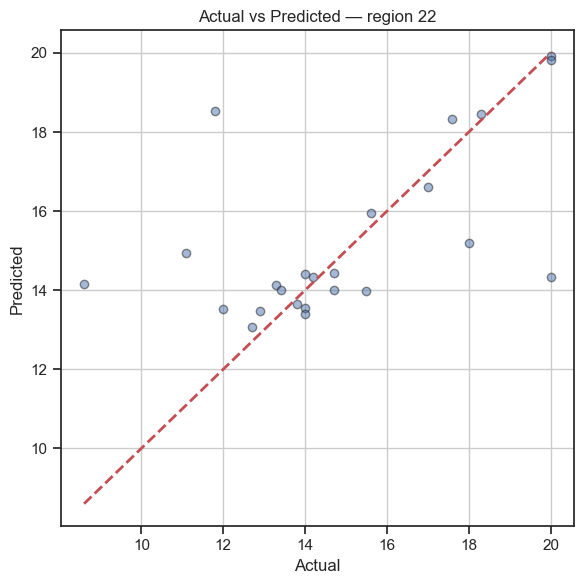

In [25]:
# plot one region
mr.plot_parity(22)

In [26]:
# top features for a region
mr.top_features(1, k=15)

,feature,importance
0,Achpy01,0.260229
1,Navcr09,0.179874
2,Navpe05,0.103764
3,Achmi02,0.059775
4,Nitpa02,0.034365
5,Coceu01,0.025488
6,Nitfo01,0.023427
7,Selni01,0.022068
8,Navsa03,0.018288
9,Gommi05,0.015034


In [ ]:
# # build/clean the new data for region 1 the same way you trained
# Xnew1 = cleandf.IWANTMYXCLEAN(df_new[df_new["HERlvl1Code"] == 1])

# # mean prediction
# yhat1 = mr.predict_region(1, Xnew1)

# # with 10/50/90% quantiles
# preds1 = mr.predict_region(1, Xnew1, return_quantiles=(0.1, 0.5, 0.9))

# # join back to rows
# df_scored = Xnew1.assign(**preds1.to_dict(orient="series"))

In [35]:
# 2) Per-region table: y_true, yhat, residual
def region_preds(mr, key: int) -> pd.DataFrame:
    r = mr.results[key]
    df = pd.DataFrame({'y_true': r['y_te'], 'yhat': r['yhat']})
    df['residual'] = df['y_true'] - df['yhat']
    return df.sort_index()

region_preds(mr, 1).head()

# 3) All regions concatenated
def all_preds(mr) -> pd.DataFrame:
    frames = []
    for key, r in mr.results.items():
        df = pd.DataFrame({'y_true': r['y_te'], 'yhat': r['yhat']})
        df['residual'] = df['y_true'] - df['yhat']
        df = df.reset_index().rename(columns={'index': 'row_id'})
        df.insert(0, 'region', key)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

preds = all_preds(mr)
preds = preds.set_index('SamplingOperations_code')
preds

,region,y_true,yhat,residual
SamplingOperations_code,,,,
S05172220_20200720,1,18.1,17.454,0.646
S05180295_20160706,1,19.4,19.043,0.357
S05199120_20220920,1,15.7,16.423,-0.723
S05181100_20130909,1,19.6,19.848,-0.248
S06169950_20090703,1,18.7,18.193,0.507
...,...,...,...,...
S03128220_20130701,22,20.0,14.333,5.667
S02123000_20170822,22,14.7,14.439,0.261
S02121500_20090805,22,18.0,15.196,2.804
